In [40]:
import pandas as pd
import numpy as np

In [41]:
from google.colab import files
uploaded = files.upload()

Saving customer_support_text_classification.csv to customer_support_text_classification (1).csv


In [42]:
df = pd.read_csv('customer_support_text_classification.csv')

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [43]:
df.shape

(1500, 6)

In [44]:
df.columns

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

In [45]:
df['sentiment_label'].value_counts()

,count
sentiment_label,
neutral,524
negative,497
positive,479


In [46]:
   print("Number of records:", df.shape)

Number of records: (1500, 6)


In [47]:
df['customer_message'].apply(lambda x: len(str(x).split())).mean()

np.float64(12.722666666666667)

The dataset contains customer messages labeled as positive, negative, and neutral. The dataset includes multiple records with varying text lengths

In [48]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['customer_message'].apply(clean_text)

 Text data was cleaned by converting to lowercase and removing special characters.

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['sentiment_label']

  TF-IDF was used to convert text into numerical form so that machine learning models can process it.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

A Logistic Regression model was built as a baseline model for sentiment classification.

In [52]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [53]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


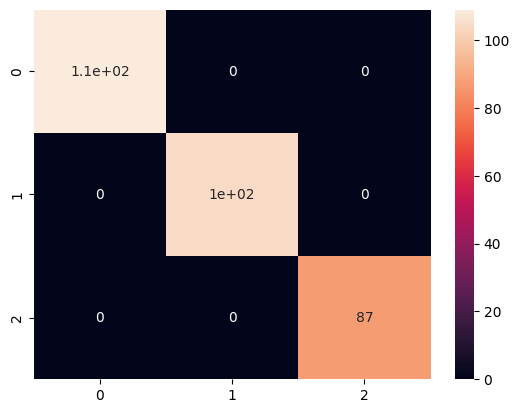

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

In [55]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_seq = pad_sequences(sequences, maxlen=50)

In [56]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_encoded, test_size=0.2, random_state=42
)

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [58]:
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [59]:
model_lstm.fit(
X_train_seq, y_train_seq,
epochs=5,
validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7117 - loss: 0.8911 - val_accuracy: 0.9567 - val_loss: 0.4268
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9825 - loss: 0.1216 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 7.9590e-04
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 1.0000 - loss: 8.1272e-04 - val_accuracy: 1.0000 - val_loss: 7.5334e-04


An LSTM model was used to capture sequence patterns and understand context in text data.

This experiment shows that while TF-IDF works well for simple classification, sequence models like LSTM better understand context in text data.

RNNs struggle with long-term dependencies. LSTMs improve this by using memory cells. Attention helps focus on important words, and transformers improve performance by processing sequences efficiently.